# Superstore Business Performance

Analyst-focused review of sales, profitability, shipping, products, customers, geography, and returned orders.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_dir = Path.cwd()
if project_dir.name == 'notebooks':
    project_dir = project_dir.parent
data_path = project_dir / 'data' / 'superstore_analysis_data.csv'
images_dir = project_dir / 'images'
images_dir.mkdir(exist_ok=True)

df = pd.read_csv(data_path, parse_dates=['Order Date', 'Ship Date'], dtype={'Postal Code': 'string'})
df['Is Returned'] = df['Is Returned'].astype(str).str.lower().isin(['true', '1', 'yes'])
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

assert len(df) == 9_994
assert df['Row ID'].is_unique
assert not df['Days to Ship'].lt(0).any()
print(f'Loaded {len(df):,} order lines across {df["Order ID"].nunique():,} orders.')

Loaded 9,994 order lines across 5,009 orders.


## KPI summary

Return rate is calculated with unique orders, not order-line rows.

In [2]:
order_flags = df.groupby('Order ID')['Is Returned'].max()
kpis = pd.Series({
    'Order lines': len(df),
    'Orders': order_flags.size,
    'Sales': df['Sales'].sum(),
    'Profit': df['Profit'].sum(),
    'Profit margin': df['Profit'].sum() / df['Sales'].sum(),
    'Returned orders': int(order_flags.sum()),
    'Returned-order rate': order_flags.mean(),
})
kpis.to_frame('Value')

,Value
Order lines,9.994000e+03
Orders,5.009000e+03
Sales,2.297201e+06
Profit,2.863970e+05
Profit margin,1.246722e-01
Returned orders,2.960000e+02
Returned-order rate,5.909363e-02


## Geographic and category performance

Top five cities by sales:


,City,Sales
329,New York City,256368.161
266,Los Angeles,175851.341
452,Seattle,119540.742
438,San Francisco,112669.092
374,Philadelphia,109077.013


Category performance:


,Category,Sales,Profit,Profit Margin
0,Furniture,741999.7953,18451.2728,0.024867
1,Office Supplies,719047.0320,122490.8008,0.170352
2,Technology,836154.0330,145454.9481,0.173957


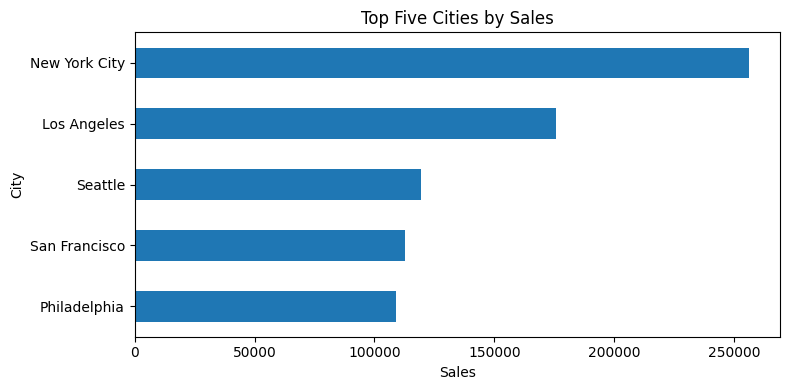

In [3]:
top_cities = (df.groupby('City', as_index=False)['Sales'].sum()
              .sort_values('Sales', ascending=False).head(5))
category = df.groupby('Category', as_index=False).agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
category['Profit Margin'] = category['Profit'] / category['Sales']
print('Top five cities by sales:')
display(top_cities)
print('Category performance:')
display(category)

ax = top_cities.sort_values('Sales').plot.barh(x='City', y='Sales', legend=False, figsize=(8,4), title='Top Five Cities by Sales')
ax.set_xlabel('Sales')
plt.tight_layout()
plt.savefig(images_dir / 'top_cities_sales.png', dpi=160, bbox_inches='tight')
plt.show()

## Product concentration (Pareto analysis)

414 of 1,862 products (22.23%) are needed to reach at least 80% of sales.


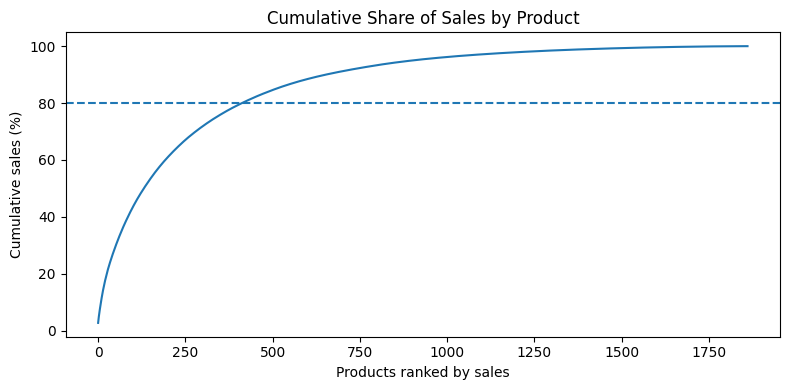

In [4]:
product_sales = df.groupby('Product ID')['Sales'].sum().sort_values(ascending=False)
cumulative_pct = product_sales.cumsum() / product_sales.sum() * 100
products_to_80 = int(cumulative_pct.lt(80).sum() + 1)
share_to_80 = products_to_80 / len(product_sales) * 100
print(f'{products_to_80:,} of {len(product_sales):,} products ({share_to_80:.2f}%) are needed to reach at least 80% of sales.')

ax = cumulative_pct.reset_index(drop=True).plot(figsize=(8,4), title='Cumulative Share of Sales by Product')
ax.axhline(80, linestyle='--')
ax.set_xlabel('Products ranked by sales')
ax.set_ylabel('Cumulative sales (%)')
plt.tight_layout()
plt.savefig(images_dir / 'product_pareto.png', dpi=160, bbox_inches='tight')
plt.show()

## Shipping duration by quarter

In [5]:
shipping = (df.groupby([df['Order Date'].dt.quarter.rename('Quarter'), 'Ship Mode'])['Days to Ship']
              .mean().unstack().round(2))
display(shipping)
print('Average shipping duration is broadly stable in Q4; no large seasonal spike appears in this dataset.')

Ship Mode,First Class,Same Day,Second Class,Standard Class
Quarter,,,,
1,2.21,0.01,3.09,4.97
2,2.12,0.09,3.20,4.97
3,2.21,0.04,3.35,5.03
4,2.20,0.04,3.24,5.03


Average shipping duration is broadly stable in Q4; no large seasonal spike appears in this dataset.


## Returned-order analysis

In [6]:
customer_orders = df[['Customer ID','Order ID','Is Returned']].drop_duplicates(['Customer ID','Order ID'])
customer_returns = customer_orders.groupby('Customer ID').agg(
    Orders=('Order ID','nunique'), Returned_Orders=('Is Returned','sum'))
customer_returns['Returned_Order_Rate'] = customer_returns['Returned_Orders'] / customer_returns['Orders']
high_returners = customer_returns[(customer_returns['Orders'] >= 2) & (customer_returns['Returned_Order_Rate'] > 0.50)]
high_returners.sort_values(['Returned_Order_Rate','Orders'], ascending=False)

,Orders,Returned_Orders,Returned_Order_Rate
Customer ID,,,
HH-15010,2,2,1.0
DE-13255,5,3,0.6


## Time from first to second order

In [7]:
orders = (df[['Customer ID','Order ID','Order Date']]
          .drop_duplicates(['Customer ID','Order ID'])
          .sort_values(['Customer ID','Order Date','Order ID']))
first_two = orders.groupby('Customer ID').head(2).copy()
first_two['Days Between Orders'] = first_two.groupby('Customer ID')['Order Date'].diff().dt.days
average_days = first_two['Days Between Orders'].mean()
print(f'Average days from first to second order: {average_days:.1f}')

Average days from first to second order: 279.0


## Findings and recommendations

- Technology has the highest sales and profit, while Furniture has a much lower profit margin.
- New York City leads city-level sales in the supplied dataset.
- Sales concentration is meaningful but not a strict 80/20 result: about 22.23% of products are needed to reach 80% of sales.
- Shipping duration remains stable across quarters, including Q4.
- Returned-order rate is approximately 5.91%; customer-level exceptions should be investigated using order-level denominators.

## Limitations

The dataset is historical and observational. It supports descriptive analysis but does not establish that any product, shipping mode, discount, or customer characteristic causes a business outcome. The original raw Orders and Returns workbook is not included.